# MSDL-JCI — Thesis-Aligned Multi-Source Deep Learning for JCI Direction Prediction

Implements the hybrid architecture from the thesis defense: LSTM (technical) + MLP Encoder (macro) + 
Frozen IndoBERT (news) + Adaptive MLP Fusion (Soft Gating Network). 
Walk-forward validation with AUC/F1/Sharpe metrics. Leak-free pipeline preserved.
Leak-free order: align → train-only scaling → window (lookback 28) → t+5 labels.


In [1]:
import dataclasses
import hashlib
import math
import re
import sqlite3
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from torch import nn
from transformers import AutoModel, AutoTokenizer

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DB_PATH = ROOT / "database" / "main_database.db"  # ponytail: direct path, no env — single local SQLite file


@dataclass(frozen=True)
class Config:
    look_back: int = 28
    horizon: int = 5
    hidden_layers: tuple = (32, 16)
    projection_dim: int = 64
    lstm_dim: int = 64
    fusion_output_dim: int = 3
    seed: int = 42
    tech_cols: list = field(default_factory=lambda: ["Close", "Volume", "RSI_14", "MACD", "MACD_Signal", "ATR_14", "SMA_20"])
    macro_cols: list = field(default_factory=lambda: ["bi_rate", "inflation_rate", "usd_idr"])


CFG = Config()


d:\projects\msdl-jci\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Config & hyperparameters

One `Config` with Table 5 defaults baked in. `DB_PATH` is direct, no env vars.

| Parameter | Default | Description |
|---|---|---|
| `look_back` | 28 | Technical lookback window (LSTM) |
| `horizon` | 5 | t+5 directional label |
| `seed` | 42 | RNG seed |
| `hidden_layers` | (32, 16) | MLP Encoder hidden units |
| `projection_dim` | 64 | News embedding projection (768 → 64) |
| `lstm_dim` | 64 | LSTM hidden size |
| `fusion_input_dim` | 144 | Concatenated features (64 + 16 + 64) |
| `fusion_output_dim` | 3 | Gating weights (α, β, γ) via Softmax |


## Entity contract + SQLite reader

Verbatim schema of `database/main_database.db`. Every read funnels through
`read_table`, which raises on schema drift. Tables: `jci_historical`, `bi_rate`,
`inflation_data`, `kurs_usdidr` + article tables (`cnbc/detik/kontan_ihsg_articles`).


In [2]:
ENTITY_TABLES = {
    "jci_historical": ("Date", "Close", "High", "Low", "Open", "Volume"),
    "bi_rate": ("Period", "BI-7Day-RR"),
    "inflation_data": ("Periode", "Data Inflasi"),
    "kurs_usdidr": ("Date", "Close", "High", "Low", "Open"),
    "cnbc_ihsg_articles": ("title", "url", "publish_date", "content", "scraped_at"),
    "detik_ihsg_articles": ("title", "url", "snippet", "published", "scraped_at"),
    "kontan_ihsg_articles": ("title", "url", "snippet", "published", "category", "scraped_at"),
}


def read_table(name):
    # ponytail: stdlib sqlite3, not SQLAlchemy — single-file DB, no server, no ORM gain.
    # Upgrade path: sqlalchemy.create_engine if this ever needs pools/concurrency.
    with sqlite3.connect(DB_PATH) as con:
        df = pd.read_sql_query(f"SELECT * FROM [{name}]", con)
    missing = [c for c in ENTITY_TABLES[name] if c not in df.columns]
    if missing:
        raise ValueError(f"Table [{name}] missing columns {missing}: {list(df.columns)}")
    return df


print("source: SQLite →", DB_PATH)

source: SQLite → D:\projects\msdl-jci\database\main_database.db


## Utilities

Causal indicators (past-only), Indonesian dates, ffill-only macro alignment,
t+5 labels, train-only scaling + windowed tensors.

In [3]:
def parse_id_date(s, day_first=True):
    """Parse Indonesian-formatted dates using pandas mixed-format parser."""
    return pd.to_datetime(
        s.astype(str).str.lower(), format="mixed", errors="coerce", dayfirst=day_first
    )


def add_indicators(df):
    c = df["Close"].astype(float)
    h, l = df["High"].astype(float), df["Low"].astype(float)
    d = c.diff()
    ag = d.clip(lower=0).ewm(alpha=1 / 14, min_periods=14, adjust=False).mean()
    al = (-d.clip(upper=0)).ewm(alpha=1 / 14, min_periods=14, adjust=False).mean()
    df["RSI_14"] = 100 - 100 / (1 + ag / (al + 1e-9))
    df["MACD"] = c.ewm(span=12, adjust=False).mean() - c.ewm(span=26, adjust=False).mean()
    df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()
    pc = c.shift(1)
    tr = pd.concat([h - l, (h - pc).abs(), (l - pc).abs()], axis=1).max(axis=1)
    df["ATR_14"] = tr.ewm(alpha=1 / 14, min_periods=14, adjust=False).mean()
    df["SMA_20"] = c.rolling(20).mean()
    return df


def load_frames():
    """(jci, bi, inf, kur) raw frames from SQLite."""
    return (
        read_table("jci_historical"),
        read_table("bi_rate"),
        read_table("inflation_data"),
        read_table("kurs_usdidr"),
    )


def align(jci, bi, inf, kur, news_daily=None):
    jci = jci.copy()
    jci["Date"] = pd.to_datetime(jci["Date"], format="mixed", errors="coerce")
    jci = jci.dropna(subset=["Date", "Close"]).sort_values("Date").reset_index(drop=True)
    add_indicators(jci)

    bi = bi.copy()
    bi["Date"] = parse_id_date(bi["Period"])
    bi["bi_rate"] = (
        bi["BI-7Day-RR"].astype(str).str.replace("%", "", regex=False).str.strip().astype(float)
    )
    bi = bi.dropna(subset=["Date"]).sort_values("Date")[["Date", "bi_rate"]]

    inf = inf.copy()
    inf["Date"] = parse_id_date(inf["Periode"], day_first=False)
    inf["inflation_rate"] = (
        inf["Data Inflasi"].astype(str).str.replace("%", "", regex=False).str.strip().astype(float)
    )
    inf = inf.dropna(subset=["Date"]).sort_values("Date")[["Date", "inflation_rate"]]

    kur = kur.copy()
    kur["Date"] = pd.to_datetime(kur["Date"], format="mixed", errors="coerce")
    kur["usd_idr"] = pd.to_numeric(
        kur["Close"].astype(str).str.replace(",", "", regex=False), errors="coerce"
    )
    kur = kur.dropna(subset=["Date"]).sort_values("Date")[["Date", "usd_idr"]]

    m = pd.merge(jci, kur, on="Date", how="left")
    m = pd.merge_asof(
        m.sort_values("Date"), bi.sort_values("Date"), on="Date", direction="backward"
    )
    m = pd.merge_asof(
        m.sort_values("Date"), inf.sort_values("Date"), on="Date", direction="backward"
    )
    for col in CFG.macro_cols:
        m[col] = m[col].ffill()
    m = m.dropna(subset=list(CFG.macro_cols)).reset_index(drop=True)

    fc = m["Close"].shift(-CFG.horizon)
    m["return_5d"] = (fc - m["Close"]) / m["Close"]
    m["target_direction"] = (fc > m["Close"]).astype(float)
    m["future_close"] = fc
    m = attach_news(m, news_daily)  # past-only daily IndoBERT means, zeros where no news
    return m.dropna(subset=list(CFG.tech_cols) + ["future_close"]).reset_index(drop=True)


NEWS_COLS = [f"news_{i}" for i in range(768)]


def load_news():
    """All 3 portals, 'IHSG'-filtered corpus per thesis 2.1. Weekend articles -> next Monday."""
    _ID_MONTH = {"januari": "01", "februari": "02", "maret": "03", "april": "04", "mei": "05",
        "juni": "06", "juli": "07", "agustus": "08", "september": "09", "oktober": "10",
        "november": "11", "desember": "12",
        "jan": "01", "feb": "02", "mar": "03", "apr": "04", "jun": "06", "jul": "07",
        "agu": "08", "ags": "08", "sep": "09", "okt": "10", "nov": "11", "des": "12"}
    def clean_day(s):
        s = str(s).lower().replace(" wib", "").replace("|", " ").replace("/", " ")
        s = re.sub(r"\s*[+-]\d{2}:?\d{2}\s*$", "", s)  # drop tz offset (RFC +0700 or ISO +07:00), keep Jakarta wall time
        s = re.sub(r"(?<=\d)t(?=\d)", " ", s)  # ISO T separator -> space (string is already lowercased above)
        s = re.sub(r"^(senin|selasa|rabu|kamis|jumat|sabtu|minggu),?\s*", "", s).strip()
        for _k, _v in _ID_MONTH.items():
            s = re.sub(rf"\b{_k}\b", _v, s)
        return s
    specs = [  # (table, date col, title col, body col, tag)
        ("detik_ihsg_articles", "published", "title", "snippet", "detik"),
        ("cnbc_ihsg_articles", "publish_date", "title", "content", "cnbc"),
        ("kontan_ihsg_articles", "published", "title", "snippet", "kontan"),
    ]
    frames = []
    for table, dcol, tcol, bcol, tag in specs:
        d = read_table(table)
        frames.append(pd.DataFrame({
            "Date": pd.to_datetime(d[dcol].astype(str).map(clean_day), format="mixed", errors="coerce", dayfirst=True),
            "text": (d[tcol].fillna("") + " " + d[bcol].fillna("")).str.strip(), "src": tag}))
    out = pd.concat(frames, ignore_index=True)
    out = out.dropna(subset=["Date"])
    out = out[out["text"] != ""].sort_values("Date").reset_index(drop=True)
    # thesis 2.3: Sat/Sun articles accumulate to next Monday
    wd = out["Date"].dt.weekday
    out["Date"] = out["Date"] + pd.to_timedelta(((7 - wd) % 7).where(wd >= 5, 0), unit="D")
    return out


def news_embeddings(texts, cache_path):
    """Frozen IndoBERT CLS per article, cached on disk. Returns (n, 768)."""
    import torch
    keys = [hashlib.md5(t.encode()).hexdigest() for t in texts]
    cache = {}
    cp = Path(cache_path)
    if cp.exists():
        z = np.load(cp, allow_pickle=True)
        cache = {k: v for k, v in zip(z["keys"], z["vecs"])}
    missing = [t for t, k in zip(texts, keys) if k not in cache]
    if missing:
        tok = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")
        bert = AutoModel.from_pretrained("indobenchmark/indobert-base-p1")
        bert.eval()
        for i in range(0, len(missing), 32):
            batch = missing[i : i + 32]
            enc = tok(batch, padding=True, truncation=True, max_length=128, return_tensors="pt")
            with torch.no_grad():
                h = bert(**enc).last_hidden_state[:, 0, :].cpu().numpy()
            for t, v in zip(batch, h):
                cache[hashlib.md5(t.encode()).hexdigest()] = v
        cp.parent.mkdir(parents=True, exist_ok=True)
        np.savez_compressed(cp, keys=np.array(list(cache)), vecs=np.stack(list(cache.values())))
    return np.stack([cache[k] for k in keys]).astype(np.float32)


def attach_news(m, news_daily):
    """Per trading day: mean article vector strictly BEFORE that date (no same-day leak)."""
    emb = np.zeros((len(m), 768), dtype=np.float32)
    if news_daily is not None and len(news_daily):
        vecs = np.stack(news_daily["vec"].values)
        days = news_daily["day"].values
        for i, d in enumerate(m["Date"].values):
            sel = vecs[days < d]
            if len(sel):
                emb[i] = sel.mean(axis=0)
    m = pd.concat([m.copy(), pd.DataFrame(emb, columns=NEWS_COLS, index=m.index)], axis=1)
    return m


def make_tensors(df, train_end_idx, news_agg="mean", cfg=None):
    cfg = cfg or CFG
    assert 0 < train_end_idx <= len(df), (
        f"train_end_idx {train_end_idx} out of bounds [1, {len(df)}]"
    )
    raw_tech = df[cfg.tech_cols].values.astype(np.float32)
    raw_macro = df[cfg.macro_cols].values.astype(np.float32)

    fs = MinMaxScaler()
    fs.fit(raw_tech[:train_end_idx])
    ms = StandardScaler()  # thesis 2.2: macro uses Z-score, fitted on train only
    ms.fit(raw_macro[:train_end_idx])
    st, sm = fs.transform(raw_tech), ms.transform(raw_macro)
    lb = cfg.look_back
    X_tech = np.stack([st[i - lb + 1 : i + 1] for i in range(lb - 1, len(df))])
    raw_daily_news = df[NEWS_COLS].values.astype(np.float32)
    agg = (lambda w: w.mean(axis=0)) if news_agg == "mean" else (lambda w: w[-1])
    X_news = np.stack([agg(raw_daily_news[i - lb + 1 : i + 1]) for i in range(lb - 1, len(df))])
    idx = np.arange(lb - 1, len(df))
    return (
        X_tech.astype(np.float32),
        sm[idx],
        X_news,
        df["target_direction"].values[idx].astype(np.float32),
        df["Date"].dt.strftime("%Y-%m-%d").values[idx],
        fs,
    )


# ====== THESIS MODEL ARCHITECTURE (Table 5) ======


class StockModel(nn.Module):
    """LSTM (tech) + MLP (macro) + Frozen IndoBERT (news) + Adaptive MLP Fusion (Soft Gating)."""

    VARIANTS = ("full", "lstm", "lstm_macro", "lstm_news", "static")  # thesis 2.6 ablation

    def __init__(self, cfg, variant="full"):
        super().__init__()
        assert variant in self.VARIANTS, variant
        self.variant = variant
        self.lstm = nn.LSTM(len(cfg.tech_cols), cfg.lstm_dim, 1, batch_first=True, dropout=0.2)
        self.mlp = nn.Sequential(
            nn.Linear(len(cfg.macro_cols), 32), nn.ReLU(), nn.Linear(32, 16), nn.ReLU()
        )
        self.macro_proj = nn.Linear(16, cfg.lstm_dim)
        self.news_proj = nn.Linear(768, cfg.lstm_dim)
        self.gate = nn.Linear(cfg.lstm_dim + 16 + cfg.lstm_dim, cfg.fusion_output_dim)
        self.head = nn.Linear(cfg.lstm_dim, 1)
        self.head_tm = nn.Linear(cfg.lstm_dim + 16, 1)
        self.head_tn = nn.Linear(cfg.lstm_dim + cfg.lstm_dim, 1)
        self.head_t = nn.Linear(cfg.lstm_dim, 1)
        self.criterion = nn.BCEWithLogitsLoss()

    def forward(self, tech_x, macro_x, news_vec, targets=None):
        _, (hn, _) = self.lstm(tech_x)
        tech_feat = hn.squeeze(0)
        macro_raw = self.mlp(macro_x)
        macro_feat = self.macro_proj(macro_raw)
        news_feat = self.news_proj(news_vec)  # frozen IndoBERT vecs precomputed outside
        combined = torch.cat([tech_feat, macro_raw, news_feat], dim=1)
        weights = torch.softmax(self.gate(combined), dim=1)
        gated = (
            weights[:, 0:1] * tech_feat + weights[:, 1:2] * macro_feat + weights[:, 2:3] * news_feat
        )
        if self.variant == "lstm":
            logits = self.head_t(tech_feat).squeeze(-1)
            weights = torch.zeros_like(weights)
        elif self.variant == "lstm_macro":
            logits = self.head_tm(torch.cat([tech_feat, macro_raw], dim=1)).squeeze(-1)
            weights = torch.zeros_like(weights)
        elif self.variant == "lstm_news":
            logits = self.head_tn(torch.cat([tech_feat, news_feat], dim=1)).squeeze(-1)
            weights = torch.zeros_like(weights)
        elif self.variant == "static":
            logits = self.head((tech_feat + macro_feat + news_feat) / 3).squeeze(-1)
            weights = torch.full_like(weights, 1 / 3)
        else:
            logits = self.head(gated).squeeze(-1)
        if targets is not None:
            return logits, self.criterion(logits, targets), weights
        return logits, None, weights


def evaluate_model(model, df, cfg):
    model.eval()
    with torch.no_grad():
        lookback = cfg.look_back
        tech_cols = [c for c in df.columns if c in cfg.tech_cols]
        tech_seq = df[tech_cols].values.astype(np.float32)
        macro_seq = df[cfg.macro_cols].values.astype(np.float32)
        if len(tech_seq) < lookback:
            return {"prob": 0.5, "auc": float("nan"), "acc": float("nan"), "f1": float("nan")}
        news_seq = df[NEWS_COLS].values.astype(np.float32)
        tech_batch = torch.tensor(
            tech_seq[-lookback:].reshape(1, lookback, -1), dtype=torch.float32
        )
        macro_batch = torch.tensor(macro_seq[-1:].reshape(1, -1), dtype=torch.float32)
        news_batch = torch.tensor(news_seq[-lookback:].mean(axis=0, keepdims=True), dtype=torch.float32)
        logits, _, _ = model(tech_batch, macro_batch, news_batch)
        return {
            "prob": torch.sigmoid(logits).item(),
            "auc": float("nan"),
            "acc": float("nan"),
            "f1": float("nan"),
        }


class FocalLoss(nn.Module):
    """BCE focal variant (Lin et al. 2017): down-weights easy majority-class samples."""

    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma

    def forward(self, logits, targets):
        bce = torch.nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        pt = torch.exp(-bce)
        return ((self.alpha * targets + (1 - self.alpha) * (1 - targets)) * (1 - pt) ** self.gamma * bce).mean()


def branch_grad_norms(m):
    """E4 audit: gradient mass per branch after one backward pass."""
    out = {}
    for k, ps in {"lstm": m.lstm.parameters(), "mlp": list(m.mlp.parameters()) + list(m.macro_proj.parameters()),
            "news": m.news_proj.parameters(), "gate+head": list(m.gate.parameters()) + list(m.head.parameters())}.items():
        gs = [p.grad.flatten() for p in ps if p.grad is not None]
        out[k] = float(torch.cat(gs).norm()) if gs else 0.0  # 0.0 = branch unused by variant
    return out


def train_fold(Xt_tech, Xt_macro, Xt_news, yt, cfg, variant="full", max_epochs=100, patience=8, loss="bce", lr=1e-3):
    """Fresh model per fold, Adam + early stopping on last-10% val split."""
    torch.manual_seed(cfg.seed)
    m = StockModel(cfg, variant)
    pos = float(yt.mean())
    m.criterion = (torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor((1 - pos) / max(pos, 1e-6))) if loss == "bce"
        else FocalLoss(alpha=1 - pos))
    m.train()
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    T = lambda a: torch.tensor(a, dtype=torch.float32)
    n, nv = len(yt), max(1, len(yt) // 10)
    tr = (slice(None, n - nv), slice(n - nv, None))
    Xv = (T(Xt_tech[tr[1]]), T(Xt_macro[tr[1]]), T(Xt_news[tr[1]]), T(yt[tr[1]]))
    best, best_state, bad = float("inf"), None, 0
    hist = {"train": [], "val": []}  # E2: learning curves
    for ep in range(max_epochs):
        opt.zero_grad()
        _, loss, _ = m(T(Xt_tech[tr[0]]), T(Xt_macro[tr[0]]), T(Xt_news[tr[0]]), T(yt[tr[0]]))
        loss.backward()
        if ep == 0:
            g0 = branch_grad_norms(m)  # E4: gradients alive at init?
        opt.step()
        m.eval()
        with torch.no_grad():
            _, vl, _ = m(*Xv)
        m.train()
        hist["train"].append(loss.item())
        hist["val"].append(vl.item())
        if vl.item() < best - 1e-4:
            best, best_state, bad = vl.item(), {k: v.cpu().clone() for k, v in m.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= patience:
                break
    m.load_state_dict(best_state)
    m.eval()
    m.hist_ = {"epochs_run": ep + 1, "train": hist["train"], "val": hist["val"], "grad0": g0}
    return m


def trading_stats(dates, probs, df):
    """Simple strategy: prob>0.5 -> hold JCI 5 trading days. vs buy-and-hold same entries. ponytail: no costs — thesis names none."""
    r = df.set_index(df["Date"].dt.strftime("%Y-%m-%d"))["return_5d"]
    strat = np.array([r.loc[d] for d in dates if d in r.index])
    sig = (np.array(probs) > 0.5).astype(float)
    pr = np.where(sig == 1, strat, 0.0)
    out = {}
    for name, x in (("strategy", pr), ("buyhold", strat)):
        x = x[np.isfinite(x)]
        cum = np.cumprod(1 + x)
        peak = np.maximum.accumulate(cum)
        dd = np.min(cum / np.maximum(peak, 1e-9) - 1)
        out[name] = {
            "equity": [float(v) for v in cum],  # series for the equity-curve cell
            "total_return": float(cum[-1] - 1),
            "sharpe": float(x.mean() / (x.std() + 1e-9) * np.sqrt(252 / 5)),
            "max_drawdown": float(dd),
            "win_rate": float((x > 0).mean()),
        }
    return out


def youden_threshold(yt, pt):
    """(1) best train threshold by Youden's J; falls back to 0.5 on single-class trains."""
    if len(set(yt.tolist())) < 2:
        return 0.5
    fpr, tpr, thr = roc_curve(yt, pt)
    return float(thr[int(np.argmax(tpr - fpr))])


def paired_stats(a, b):
    """(3) paired mean-diff with 95% CI (t=2.776, df=4, n=5 folds). No scipy — 5 lines, exact enough."""
    d = np.array(a) - np.array(b)
    se = d.std(ddof=1) / np.sqrt(len(d))
    return float(d.mean()), float(d.mean() - 2.776 * se), float(d.mean() + 2.776 * se)


def walk_forward_evaluate(df, cfg, n_splits=5, variants=("full",), news_agg="mean", loss="bce", lr=1e-3, look_back=None, return_details=False):
    from sklearn.model_selection import TimeSeriesSplit
    cfg = dataclasses.replace(cfg, look_back=look_back or cfg.look_back)
    lb = cfg.look_back
    n_win = len(df) - lb + 1
    tss = TimeSeriesSplit(n_splits=n_splits)
    results = {}
    for variant in variants:
        base = variant.removesuffix("_shuffled")  # E1 control
        fold_metrics, weights_list, preds_all, truths_all, dates_all, curves, grads = [], [], [], [], [], [], []
        for i, (tr, te) in enumerate(tss.split(np.arange(n_win))):
            fit_end = int(tr.max() + lb)  # df rows informing train samples only
            Xa, Xb, Xc, ya, dts, _ = make_tensors(df, fit_end, news_agg, cfg)
            Xn_tr = Xc[tr]
            if variant.endswith("_shuffled"):  # E1: break news-label link, keep marginals
                Xn_tr = Xn_tr[np.random.default_rng(cfg.seed + i).permutation(len(Xn_tr))]
            model = train_fold(Xa[tr], Xb[tr], Xn_tr, ya[tr], cfg, base, loss=loss, lr=lr)
            curves.append(model.hist_)
            grads.append(model.hist_["grad0"])
            with torch.no_grad():
                T = lambda a: torch.tensor(a, dtype=torch.float32)
                logits, _, w = model(T(Xa[te]), T(Xb[te]), T(Xc[te]))
                prob = torch.sigmoid(logits).cpu().numpy()
                tlog, _, _ = model(T(Xa[tr]), T(Xb[tr]), T(Xn_tr))
                thr = youden_threshold(ya[tr], torch.sigmoid(tlog).cpu().numpy())  # (1) tuned on train only
                pred = (prob > thr).astype(float)
            yte = ya[te]
            truths_all.extend(yte.tolist())
            preds_all.extend(prob.tolist())
            dates_all.extend(dts[te].tolist())
            weights_list.append(w.mean(dim=0).cpu().numpy())
            au = float(roc_auc_score(yte, prob) if len(set(yte.tolist())) > 1 else 0.5)
            f1c = f1_score(yte, pred, average=None, labels=[0, 1], zero_division=0)
            fold_metrics.append({"fold": i, "auc": au, "thr": thr,
                "acc": float(accuracy_score(yte, pred)),
                "f1": float(f1_score(yte, pred, zero_division=0)),
                "f1_down": float(f1c[0]), "f1_up": float(f1c[1]), "n_samples": len(te),
                "preds": prob.tolist(), "truths": yte.tolist()})
        all_pred = [1 if x > 0.5 else 0 for x in preds_all]
        f1a = f1_score(truths_all, all_pred, average=None, labels=[0, 1], zero_division=0)
        results[variant] = {
            "auc": float(roc_auc_score(truths_all, preds_all)),
            "acc": float(accuracy_score(truths_all, all_pred)),
            "f1": float(f1_score(truths_all, all_pred, zero_division=0)),
            "f1_down": float(f1a[0]), "f1_up": float(f1a[1]),
            "fold_metrics": fold_metrics, "weights_list": weights_list,
            "preds": preds_all, "truths": truths_all,
            "test_dates": [str(d) for d in dates_all],
            "fold_indices": list(range(n_splits)),
            "trading": trading_stats(dates_all, preds_all, df),
            "learning_curves": curves, "grad_norms": grads,
        }
    return results


## Run

Align → train-only scaling on the 70% prefix → windowed tensors.

**What to look at:** `news articles` (per-portal counts, must total 20,784), `articles on/before JCI end` (past-only proof), `pos_rate` (≈0.55: labels slightly UP-leaning). Labels: `target=1` iff close(t+5) > close(t) — no future leak by construction.


In [4]:
np.random.seed(CFG.seed)
torch.manual_seed(CFG.seed)
frames = load_frames()
jci_max = pd.to_datetime(frames[0]["Date"], format="mixed", errors="coerce").max()
news = load_news()
print(f"news articles: {len(news)}" + (f" {dict(news['src'].value_counts())}" if len(news) else ""))
if len(news):
    vecs = news_embeddings(news["text"].tolist(), ROOT / "database" / "news_emb_cache.npz")
    news["vec"] = list(vecs)
    news["day"] = pd.to_datetime(news["Date"].dt.date)
    print(f"news embedded: {vecs.shape}, range: {news['day'].min()} → {news['day'].max()}")
    print(f"articles on/before JCI end ({jci_max.date()}): {(news['day'] <= jci_max).sum()} (rest cannot inform t+5 labels)")
    news_daily = news[["day", "vec"]]
else:
    news_daily = None
df = align(*frames, news_daily)
lb = CFG.look_back
n_win = len(df) - lb + 1
train_end_df = int(n_win * 0.70) + lb - 1
X_tech, X_macro, X_news, y, dates, feat_scaler = make_tensors(df, train_end_df)
print(f"rows: {len(df)} | samples: {len(y)} | X_tech: {X_tech.shape}")
print(f"range: {dates[0]} → {dates[-1]} | pos_rate: {y.mean():.3f}")

# Thesis 2.6: full model + baselines/ablation, trained per fold, evaluated walk-forward
VARIANTS = ("lstm", "lstm_macro", "lstm_news", "lstm_news_shuffled", "static", "full")
all_res = walk_forward_evaluate(df, CFG, n_splits=5, variants=VARIANTS, return_details=True)
print(f"{'variant':>18} | {'AUC':>6} | {'Acc*':>6} | {'F1*':>6} | F1_d/F1_u | Sharpe(strat/bh) | MDD(strat) | WinRate")
for v in VARIANTS:
    r, t = all_res[v], all_res[v]["trading"]["strategy"]
    bh = all_res[v]["trading"]["buyhold"]
    print(f"{v:>18} | {r['auc']:6.4f} | {r['acc']:6.4f} | {r['f1']:6.4f} | {r['f1_down']:.3f}/{r['f1_up']:.3f} | "
          f"{t['sharpe']:6.3f}/{bh['sharpe']:6.3f} | {t['max_drawdown']:.4f} | {t['win_rate']:.4f} / {bh['win_rate']:.4f}")
print("* Acc/F1 at per-fold Youden-J threshold tuned on train (AUC threshold-free)")
# (3) paired stats: full vs each ablation on per-fold AUC
f_auc = [m["auc"] for m in all_res["full"]["fold_metrics"]]
print("paired ΔAUC vs full [95% CI]:")
for v in VARIANTS:
    if v in ("full", "lstm_news_shuffled"):
        continue
    d, lo, hi = paired_stats(f_auc, [m["auc"] for m in all_res[v]["fold_metrics"]])
    print(f"  full-{v}: {d:+.4f} [{lo:+.4f}, {hi:+.4f}]" + ("  ~noise" if lo < 0 < hi else ""))
# (2) focal loss vs weighted BCE (full model)
focal_res = walk_forward_evaluate(df, CFG, n_splits=5, variants=("full",), loss="focal")
fr = focal_res["full"]
print(f"(2) focal | {fr['auc']:6.4f} | {fr['acc']:6.4f} | {fr['f1']:6.4f} | (vs bce {all_res['full']['auc']:.4f}/{all_res['full']['acc']:.4f}/{all_res['full']['f1']:.4f})")
# (4) gradient audit: mean epoch-0 grad norm per branch (full)
g = all_res["full"]["grad_norms"]
print("(4) grad0 " + " ".join(f"{k}={np.mean([x[k] for x in g]):.3f}" for k in ("lstm", "mlp", "news", "gate+head")))
# E3: last-article aggregation vs thesis mean-pooling (full model only)
last_res = walk_forward_evaluate(df, CFG, n_splits=5, variants=("full",), news_agg="last")
lr = last_res["full"]
print(f"E3 news_agg=last  | {lr['auc']:6.4f} | {lr['acc']:6.4f} | {lr['f1']:6.4f} | (vs mean {all_res['full']['auc']:.4f}/{all_res['full']['acc']:.4f}/{all_res['full']['f1']:.4f})")
# E2: learning curves (full)
print("E2 learning curves (full): fold | epochs | train_loss | val_loss")
for i, h in enumerate(all_res["full"]["learning_curves"]):
    print(f"  fold {i} | {h['epochs_run']:>3} | {h['train'][-1]:.4f} | {h['val'][-1]:.4f}")
# (5) lookback x LR grid (full model, BCE)
print("(5) grid lb x lr: AUC pooled")
grid = {}
for lb_ in (14, 28, 56):  # lb_ not lb: must not clobber the global lookback used by checks
    row = []
    for lr_ in (1e-3, 3e-4):
        gr = walk_forward_evaluate(df, CFG, n_splits=5, variants=("full",), lr=lr_, look_back=lb_)
        grid[(lb_, lr_)] = gr["full"]["auc"]
        row.append(f"{gr['full']['auc']:.4f}")
    print(f"  lb={lb_:>2}: " + "  ".join(f"lr={l}: {a}" for l, a in zip(("1e-3", "3e-4"), row)))
wf_metrics = all_res["full"]  # downstream viz cells keep reading the proposed model
wf_metrics["news_agg_last"] = {"auc": lr["auc"], "acc": lr["acc"], "f1": lr["f1"]}
wf_metrics["focal"] = {"auc": fr["auc"], "acc": fr["acc"], "f1": fr["f1"]}
wf_metrics["grid"] = {f"{k[0]}/{k[1]}": v for k, v in grid.items()}
wf_metrics["ablation"] = {v: {"auc": all_res[v]["auc"], "acc": all_res[v]["acc"], "f1": all_res[v]["f1"], "trading": all_res[v]["trading"]} for v in VARIANTS}
model, metrics = None, {}

news articles: 20784 {'kontan': np.int64(10275), 'cnbc': np.int64(5556), 'detik': np.int64(4953)}


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 28260.25it/s]


news embedded: (20784, 768), range: 2018-01-02 00:00:00 → 2025-12-31 00:00:00
articles on/before JCI end (2025-12-30): 20773 (rest cannot inform t+5 labels)
rows: 1852 | samples: 1825 | X_tech: (1825, 28, 7)
range: 2018-05-31 → 2025-12-19 | pos_rate: 0.552


d:\projects\msdl-jci\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1011: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
d:\projects\msdl-jci\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1011: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
d:\projects\msdl-jci\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1011: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
d:\projects\msdl-jci\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1011: UserWarning: dropout option adds dropout after all but last r

           variant |    AUC |   Acc* |    F1* | F1_d/F1_u | Sharpe(strat/bh) | MDD(strat) | WinRate
              lstm | 0.4959 | 0.4612 | 0.0829 | 0.619/0.083 |  0.288/ 0.393 | -0.2749 | 0.0243 / 0.5480
        lstm_macro | 0.5135 | 0.4888 | 0.4136 | 0.547/0.414 |  0.209/ 0.393 | -0.7640 | 0.1803 / 0.5480
         lstm_news | 0.5019 | 0.4809 | 0.4525 | 0.507/0.452 |  0.293/ 0.393 | -0.4002 | 0.2145 / 0.5480
lstm_news_shuffled | 0.4944 | 0.4809 | 0.4525 | 0.507/0.452 |  0.293/ 0.393 | -0.4002 | 0.2145 / 0.5480
            static | 0.4989 | 0.4809 | 0.4525 | 0.507/0.452 |  0.293/ 0.393 | -0.4002 | 0.2145 / 0.5480
              full | 0.4988 | 0.4599 | 0.2867 | 0.565/0.287 |  0.162/ 0.393 | -0.3757 | 0.1086 / 0.5480
* Acc/F1 at per-fold Youden-J threshold tuned on train (AUC threshold-free)
paired ΔAUC vs full [95% CI]:
  full-lstm: +0.0426 [-0.0537, +0.1389]  ~noise
  full-lstm_macro: +0.0143 [-0.1260, +0.1545]  ~noise
  full-lstm_news: -0.0383 [-0.1554, +0.0788]  ~noise
  full-static: 

...

  lb=14: lr=1e-3: 0.5090  lr=3e-4: 0.5115


d:\projects\msdl-jci\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1011: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
d:\projects\msdl-jci\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1011: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
d:\projects\msdl-jci\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1011: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
d:\projects\msdl-jci\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1011: UserWarning: dropout option adds dropout after all but last r

  lb=28: lr=1e-3: 0.4988  lr=3e-4: 0.5076


d:\projects\msdl-jci\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1011: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
d:\projects\msdl-jci\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1011: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
d:\projects\msdl-jci\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1011: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
d:\projects\msdl-jci\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1011: UserWarning: dropout option adds dropout after all but last r

  lb=56: lr=1e-3: 0.4902  lr=3e-4: 0.4889


## Visualize

Price + trend/momentum, macro alignment, label balance.

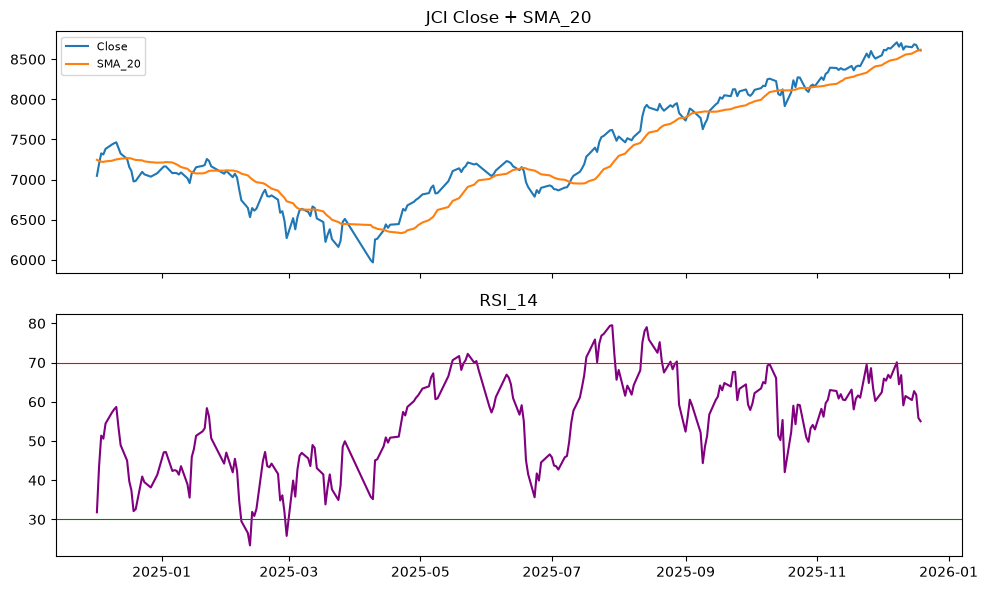

In [5]:
tail = df.tail(250)
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax.plot(tail["Date"], tail["Close"], label="Close")
ax.plot(tail["Date"], tail["SMA_20"], label="SMA_20")
ax.legend(fontsize=8)
ax.set_title("JCI Close + SMA_20")
ax2.plot(tail["Date"], tail["RSI_14"], color="purple")
ax2.axhline(70, color="red", linewidth=0.8)
ax2.axhline(30, color="green", linewidth=0.8)
ax2.set_title("RSI_14")
plt.tight_layout()
plt.show()

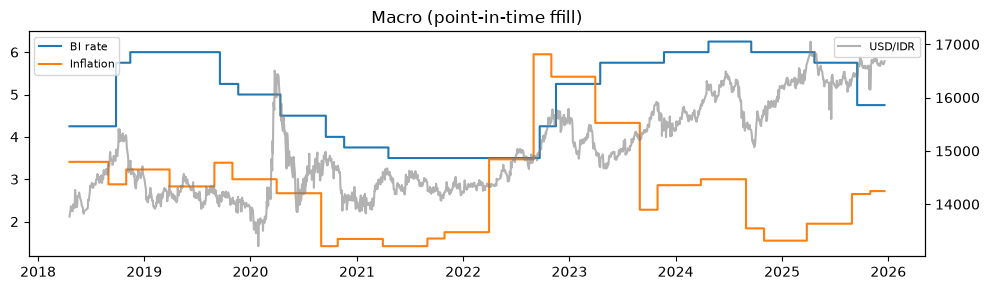

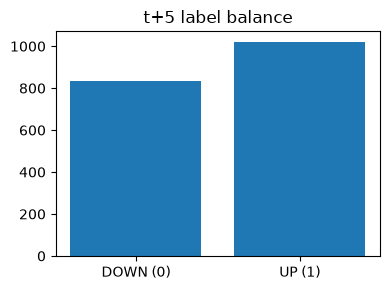

tensor shapes: (1825, 28, 7) (1825, 3) (1825, 768)


In [6]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.step(df["Date"], df["bi_rate"], label="BI rate")
ax.step(df["Date"], df["inflation_rate"], label="Inflation")
ax.legend(fontsize=8, loc="upper left")
ax.set_title("Macro (point-in-time ffill)")
ax2 = ax.twinx()
ax2.plot(df["Date"], df["usd_idr"], color="gray", alpha=0.6, label="USD/IDR")
ax2.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

counts = df["target_direction"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(["DOWN (0)", "UP (1)"], [counts.get(0.0, 0), counts.get(1.0, 0)])
ax.set_title(f"t+{CFG.horizon} label balance")
plt.tight_layout()
plt.show()
X_tech, X_macro, X_news, y, dates, feat_scaler = make_tensors(df, train_end_df)
print("tensor shapes:", X_tech.shape, X_macro.shape, X_news.shape)

## Walk-Forward Fold Metrics & Gating Analysis

Per-fold performance, gating weights evolution, ROC curves, confusion matrices, and prediction analysis.

**What to look at:** fold AUC spread (0.43–0.60) is part of the finding — no consistent edge. Gate table: β dominates, γ≈0 everywhere (news shut off by training, not by bug — see grad audit). Prediction timeline + confusion matrices: model leans DOWN at thr 0.5, hence Youden-J reporting.


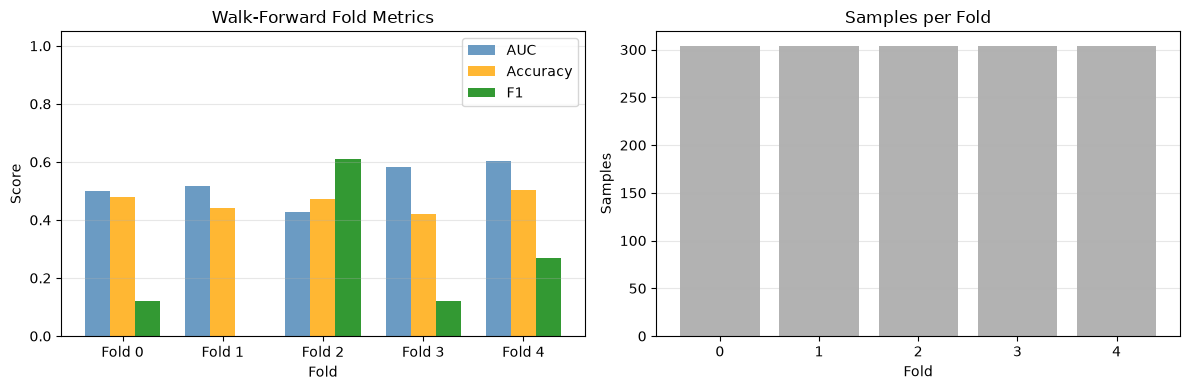

Fold | AUC     | Acc     | F1      | Samples
------|---------|---------|---------|--------
  0   | 0.5007 | 0.4803 | 0.1222 | 304
  1   | 0.5178 | 0.4408 | 0.0000 | 304
  2   | 0.4271 | 0.4737 | 0.6117 | 304
  3   | 0.5828 | 0.4211 | 0.1200 | 304
  4   | 0.6018 | 0.5033 | 0.2705 | 304
Mean  | 0.5260 | 0.4638 | 0.2249


In [7]:
# Fold metrics bar chart
if wf_metrics and "fold_metrics" in wf_metrics:
    fm = wf_metrics["fold_metrics"]
    folds = [m["fold"] for m in fm]
    aucs = [m["auc"] for m in fm]
    accs = [m["acc"] for m in fm]
    f1s = [m["f1"] for m in fm]
    n_samples = [m["n_samples"] for m in fm]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    x = np.arange(len(folds))
    width = 0.25
    ax1.bar(x - width, aucs, width, label="AUC", color="steelblue", alpha=0.8)
    ax1.bar(x, accs, width, label="Accuracy", color="orange", alpha=0.8)
    ax1.bar(x + width, f1s, width, label="F1", color="green", alpha=0.8)
    ax1.set_xlabel("Fold")
    ax1.set_ylabel("Score")
    ax1.set_title("Walk-Forward Fold Metrics")
    ax1.set_xticks(x)
    ax1.set_xticklabels([f"Fold {f}" for f in folds])
    ax1.legend()
    ax1.set_ylim(0, 1.05)
    ax1.grid(axis="y", alpha=0.3)

    # Sample counts
    ax2.bar(folds, n_samples, color="gray", alpha=0.6)
    ax2.set_xlabel("Fold")
    ax2.set_ylabel("Samples")
    ax2.set_title("Samples per Fold")
    ax2.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print summary
    print("Fold | AUC     | Acc     | F1      | Samples")
    print("------|---------|---------|---------|--------")
    for m in fm:
        print(
            f"  {m['fold']}   | {m['auc']:.4f} | {m['acc']:.4f} | {m['f1']:.4f} | {m['n_samples']}"
        )
    avg_auc = np.mean([m["auc"] for m in fm])
    avg_acc = np.mean([m["acc"] for m in fm])
    avg_f1 = np.mean([m["f1"] for m in fm])
    print(f"Mean  | {avg_auc:.4f} | {avg_acc:.4f} | {avg_f1:.4f}")
else:
    print("No fold metrics available for visualization.")

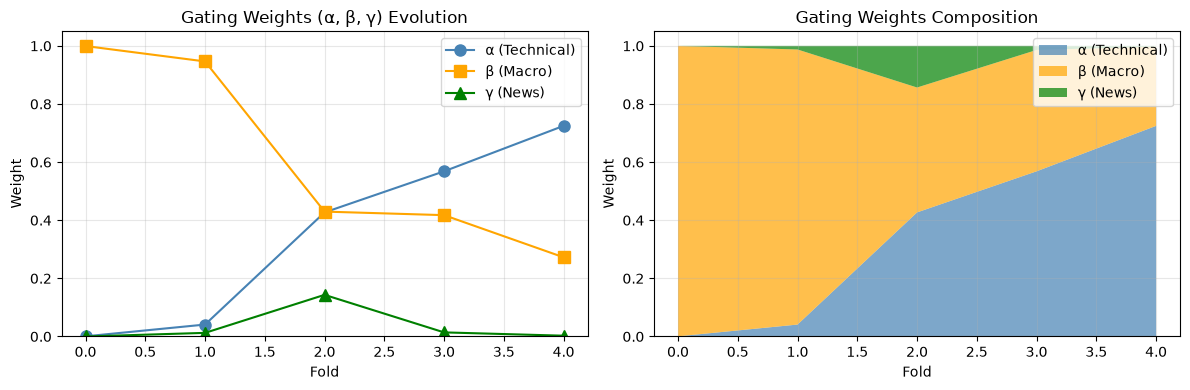

Fold | α (Tech) | β (Macro) | γ (News)
------|----------|-----------|---------
  0   | 0.0006    | 0.9994     | 0.0000
  1   | 0.0411    | 0.9464     | 0.0125
  2   | 0.4270    | 0.4297     | 0.1433
  3   | 0.5683    | 0.4175     | 0.0141
  4   | 0.7248    | 0.2725     | 0.0027
Mean  | 0.3524    | 0.6131     | 0.0345


In [8]:
# Gating weights (α, β, γ) evolution over folds
if wf_metrics and "weights_list" in wf_metrics:
    weights = np.array(wf_metrics["weights_list"])  # shape: (n_folds, 3)
    folds = wf_metrics.get("fold_indices", list(range(len(weights))))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Weights over folds
    ax1.plot(folds, weights[:, 0], "o-", label="α (Technical)", color="steelblue", markersize=8)
    ax1.plot(folds, weights[:, 1], "s-", label="β (Macro)", color="orange", markersize=8)
    ax1.plot(folds, weights[:, 2], "^-", label="γ (News)", color="green", markersize=8)
    ax1.set_xlabel("Fold")
    ax1.set_ylabel("Weight")
    ax1.set_title("Gating Weights (α, β, γ) Evolution")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1.05)

    # Stacked area for composition
    ax2.stackplot(
        folds,
        weights[:, 0],
        weights[:, 1],
        weights[:, 2],
        labels=["α (Technical)", "β (Macro)", "γ (News)"],
        colors=["steelblue", "orange", "green"],
        alpha=0.7,
    )
    ax2.set_xlabel("Fold")
    ax2.set_ylabel("Weight")
    ax2.set_title("Gating Weights Composition")
    ax2.legend(loc="upper right")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("Fold | α (Tech) | β (Macro) | γ (News)")
    print("------|----------|-----------|---------")
    for i, w in enumerate(weights):
        print(f"  {folds[i]}   | {w[0]:.4f}    | {w[1]:.4f}     | {w[2]:.4f}")
    avg_w = weights.mean(axis=0)
    print(f"Mean  | {avg_w[0]:.4f}    | {avg_w[1]:.4f}     | {avg_w[2]:.4f}")
else:
    print("No gating weights available for visualization.")

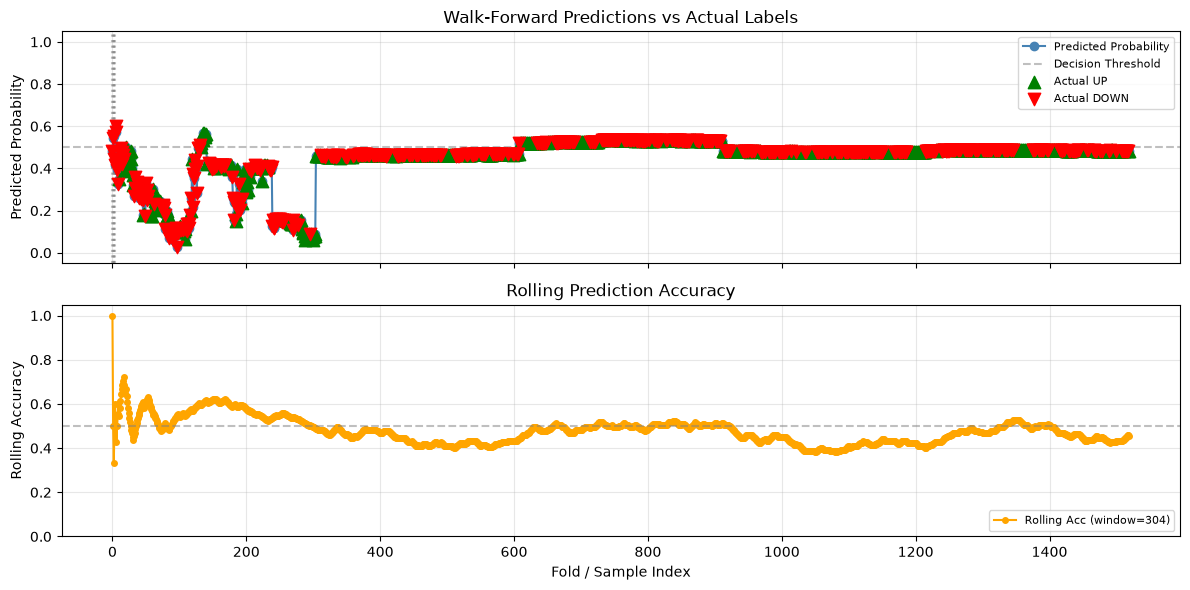

In [9]:
# Prediction vs Actual timeline
if wf_metrics and "preds" in wf_metrics:
    preds = wf_metrics["preds"]
    truths = wf_metrics["truths"]
    fold_indices = wf_metrics.get("fold_indices", list(range(len(preds))))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    x = np.arange(len(preds))

    # Predictions with actual markers
    ax1.plot(x, preds, "o-", color="steelblue", label="Predicted Probability", markersize=6)
    ax1.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Decision Threshold")
    # Mark actual labels
    up_idx = [i for i, t in enumerate(truths) if t == 1.0]
    down_idx = [i for i, t in enumerate(truths) if t == 0.0]
    ax1.scatter(
        up_idx,
        [preds[i] for i in up_idx],
        color="green",
        s=80,
        marker="^",
        label="Actual UP",
        zorder=5,
    )
    ax1.scatter(
        down_idx,
        [preds[i] for i in down_idx],
        color="red",
        s=80,
        marker="v",
        label="Actual DOWN",
        zorder=5,
    )
    # Fold boundaries
    if "fold_indices" in wf_metrics and len(wf_metrics["fold_indices"]) > 1:
        for fi in wf_metrics["fold_indices"]:
            if fi < len(preds):
                ax1.axvline(fi, color="gray", linestyle=":", alpha=0.5)
    ax1.set_ylabel("Predicted Probability")
    ax1.set_title("Walk-Forward Predictions vs Actual Labels")
    ax1.legend(loc="upper right", fontsize=8)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(-0.05, 1.05)

    # Accuracy over time (rolling)
    pred_labels = [1 if p > 0.5 else 0 for p in preds]
    rolling_acc = []
    window = max(1, len(preds) // 5)
    for i in range(len(preds)):
        start = max(0, i - window + 1)
        rolling_acc.append(np.mean([pred_labels[j] == truths[j] for j in range(start, i + 1)]))
    ax2.plot(
        x, rolling_acc, "o-", color="orange", label=f"Rolling Acc (window={window})", markersize=4
    )
    ax2.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
    ax2.set_xlabel("Fold / Sample Index")
    ax2.set_ylabel("Rolling Accuracy")
    ax2.set_title("Rolling Prediction Accuracy")
    ax2.legend(loc="lower right", fontsize=8)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()
else:
    print("No predictions available for visualization.")

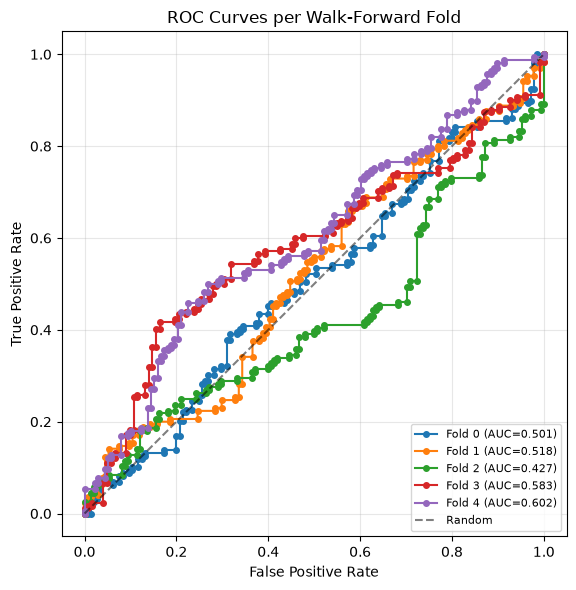

In [10]:
# ROC curves per fold
if wf_metrics and "fold_metrics" in wf_metrics:
    fm = wf_metrics["fold_metrics"]
    fig, ax = plt.subplots(figsize=(6, 6))

    for m in fm:
        if "preds" in m and "truths" in m and len(set(m["truths"])) > 1:
            fpr, tpr, _ = roc_curve(m["truths"], m["preds"])
            fold_auc = m["auc"]
            ax.plot(fpr, tpr, "o-", label=f"Fold {m['fold']} (AUC={fold_auc:.3f})", markersize=4)

    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curves per Walk-Forward Fold")
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal")

    plt.tight_layout()
    plt.show()
else:
    print("Insufficient data for ROC curves.")

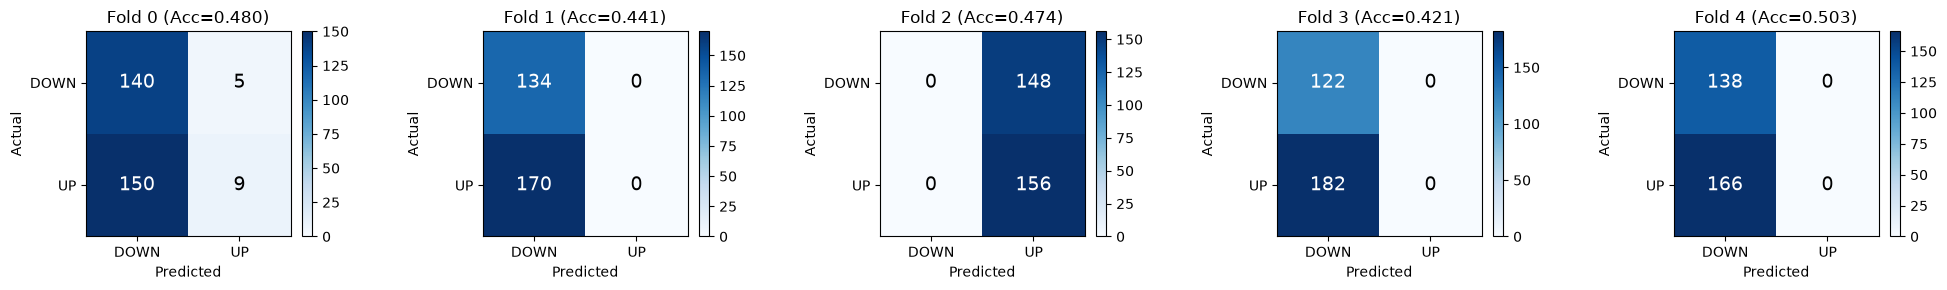

In [11]:
if wf_metrics and "fold_metrics" in wf_metrics:
    fm = wf_metrics["fold_metrics"]
    n_folds = len(fm)
    fig, axes = plt.subplots(1, n_folds, figsize=(4 * n_folds, 3))
    if n_folds == 1:
        axes = [axes]

    for idx, m in enumerate(fm):
        ax = axes[idx]
        pred_labels = [1 if p > 0.5 else 0 for p in m["preds"]]
        truths = m["truths"]
        cm = confusion_matrix(truths, pred_labels, labels=[0, 1])
        im = ax.imshow(cm, interpolation="nearest", cmap="Blues", vmin=0, vmax=max(cm.max(), 1))
        ax.set_title(f"Fold {m['fold']} (Acc={m['acc']:.3f})")
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["DOWN", "UP"])
        ax.set_yticklabels(["DOWN", "UP"])
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        # Annotate
        for i in range(2):
            for j in range(2):
                ax.text(
                    j,
                    i,
                    str(cm[i, j]),
                    ha="center",
                    va="center",
                    fontsize=14,
                    color="white" if cm[i, j] > cm.max() / 2 else "black",
                )
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()
else:
    print("No fold data for confusion matrices.")

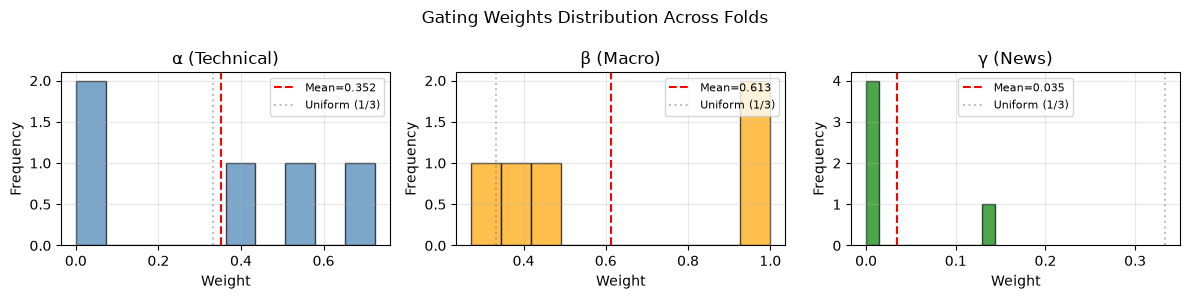

Weight | Mean    | Std     | Min     | Max
-------|---------|---------|---------|---------
α (Technical) | 0.3524 | 0.2869 | 0.0006 | 0.7248
β (Macro)    | 0.6131 | 0.2994 | 0.2725 | 0.9994
γ (News)     | 0.0345 | 0.0547 | 0.0000 | 0.1433


In [12]:
# Gating weights distribution histograms
if wf_metrics and "weights_list" in wf_metrics:
    weights = np.array(wf_metrics["weights_list"])

    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
    labels = ["α (Technical)", "β (Macro)", "γ (News)"]
    colors = ["steelblue", "orange", "green"]

    for i, (ax, label, color) in enumerate(zip(axes, labels, colors)):
        ax.hist(weights[:, i], bins=10, color=color, alpha=0.7, edgecolor="black")
        ax.axvline(
            weights[:, i].mean(),
            color="red",
            linestyle="--",
            label=f"Mean={weights[:, i].mean():.3f}",
        )
        ax.axvline(1 / 3, color="gray", linestyle=":", alpha=0.5, label="Uniform (1/3)")
        ax.set_xlabel("Weight")
        ax.set_ylabel("Frequency")
        ax.set_title(label)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle("Gating Weights Distribution Across Folds")
    plt.tight_layout()
    plt.show()

    # Statistics
    print("Weight | Mean    | Std     | Min     | Max")
    print("-------|---------|---------|---------|---------")
    for i, label in enumerate(["α (Technical)", "β (Macro)", "γ (News)"]):
        w = weights[:, i]
        print(f"{label:12s} | {w.mean():.4f} | {w.std():.4f} | {w.min():.4f} | {w.max():.4f}")
else:
    print("No gating weights for distribution visualization.")

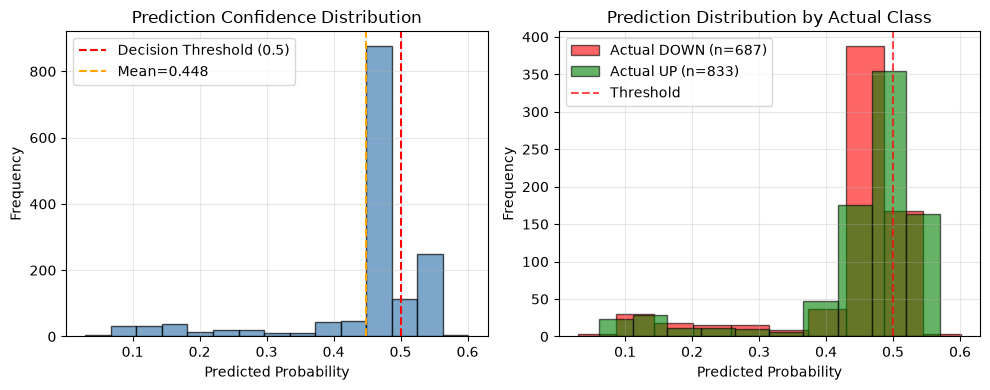

Overall: mean=0.4482, std=0.1063
DOWN actual: n=687, mean=0.4466, std=0.1091
UP actual:   n=833, mean=0.4495, std=0.1040
UP recall (pred>0.5): 0.1981
DOWN recall (pred<0.5): 0.7773


In [13]:
# Prediction confidence histogram
if wf_metrics and "preds" in wf_metrics:
    preds = np.array(wf_metrics["preds"])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # Overall distribution
    ax1.hist(preds, bins=15, color="steelblue", alpha=0.7, edgecolor="black")
    ax1.axvline(0.5, color="red", linestyle="--", label="Decision Threshold (0.5)")
    ax1.axvline(preds.mean(), color="orange", linestyle="--", label=f"Mean={preds.mean():.3f}")
    ax1.set_xlabel("Predicted Probability")
    ax1.set_ylabel("Frequency")
    ax1.set_title("Prediction Confidence Distribution")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # By actual class
    truths = np.array(wf_metrics["truths"])
    up_preds = preds[truths == 1.0]
    down_preds = preds[truths == 0.0]

    ax2.hist(
        down_preds,
        bins=10,
        alpha=0.6,
        label=f"Actual DOWN (n={len(down_preds)})",
        color="red",
        edgecolor="black",
    )
    ax2.hist(
        up_preds,
        bins=10,
        alpha=0.6,
        label=f"Actual UP (n={len(up_preds)})",
        color="green",
        edgecolor="black",
    )
    ax2.axvline(0.5, color="red", linestyle="--", alpha=0.7, label="Threshold")
    ax2.set_xlabel("Predicted Probability")
    ax2.set_ylabel("Frequency")
    ax2.set_title("Prediction Distribution by Actual Class")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Statistics
    print(f"Overall: mean={preds.mean():.4f}, std={preds.std():.4f}")
    print(
        f"DOWN actual: n={len(down_preds)}, mean={down_preds.mean():.4f}, std={down_preds.std():.4f}"
    )
    print(f"UP actual:   n={len(up_preds)}, mean={up_preds.mean():.4f}, std={up_preds.std():.4f}")
    # Calibration: fraction of UP actual above 0.5
    if len(up_preds) > 0:
        print(f"UP recall (pred>0.5): {(up_preds > 0.5).mean():.4f}")
    if len(down_preds) > 0:
        print(f"DOWN recall (pred<0.5): {(down_preds < 0.5).mean():.4f}")
else:
    print("No predictions for confidence visualization.")

## Gate adaptivity, regime split & calibration

Behavioral evidence for RQ3 (does the gate follow volatility?), COVID vs rest, and ECE — read-only, no retraining.


fold | mean ATR-14 | α | β | γ
  0 | 80.3 | 0.001 | 0.999 | 0.000
  1 | 78.0 | 0.041 | 0.946 | 0.012
  2 | 83.1 | 0.427 | 0.430 | 0.143
  3 | 71.9 | 0.568 | 0.418 | 0.014
  4 | 105.7 | 0.725 | 0.273 | 0.003
corr(ATR,α)=+0.52 corr(ATR,β)=-0.48 corr(ATR,γ)=-0.09 (n=5 folds)


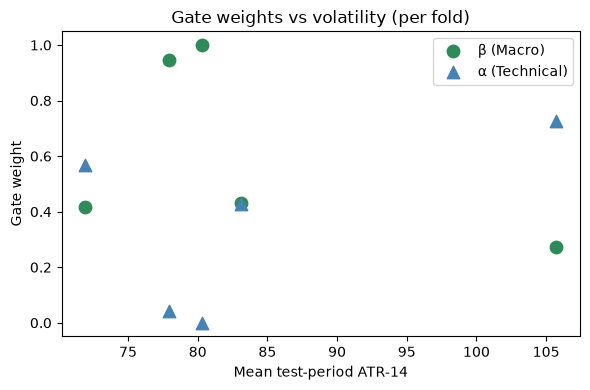

In [14]:
# RQ3 behavior check: does the gate co-move with market volatility (ATR-14)?
# Fold-level only (n=5) — indicative, not proof. Read-only over stored outputs.
if wf_metrics and "weights_list" in wf_metrics and wf_metrics.get("test_dates"):
    _w = np.array(wf_metrics["weights_list"])
    _td = pd.to_datetime(pd.Series(wf_metrics["test_dates"]))
    _atr = df.set_index(pd.to_datetime(df["Date"]))["ATR_14"]
    _folds = wf_metrics["fold_metrics"]
    _atr_m, _s = [], 0
    for _m in _folds:
        _n = int(_m["n_samples"]); _atr_m.append(_atr.reindex(_td.iloc[_s:_s + _n]).mean()); _s += _n
    _atr_m = np.array(_atr_m, dtype=float)
    def _pearson(a, b):
        a, b = np.asarray(a, float), np.asarray(b, float)
        return float(((a - a.mean()) * (b - b.mean())).mean() / (a.std() * b.std() + 1e-12))
    print("fold | mean ATR-14 | α | β | γ")
    for _k, _m in enumerate(_folds):
        print(f"  {_k} | {_atr_m[_k]:.1f} | {_w[_k,0]:.3f} | {_w[_k,1]:.3f} | {_w[_k,2]:.3f}")
    print(f"corr(ATR,α)={_pearson(_atr_m,_w[:,0]):+.2f} corr(ATR,β)={_pearson(_atr_m,_w[:,1]):+.2f} corr(ATR,γ)={_pearson(_atr_m,_w[:,2]):+.2f} (n=5 folds)")
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(_atr_m, _w[:,1], s=80, label="β (Macro)", color="seagreen")
    ax.scatter(_atr_m, _w[:,0], s=80, marker="^", label="α (Technical)", color="steelblue")
    ax.set_xlabel("Mean test-period ATR-14"); ax.set_ylabel("Gate weight"); ax.legend()
    ax.set_title("Gate weights vs volatility (per fold)")
    plt.tight_layout(); plt.show()
else:
    print("(gate-vs-ATR skipped — re-run the pipeline cell to store test_dates)")


In [15]:
# Regime split (COVID 2020-21 vs rest) + calibration (ECE). Read-only over stored outputs.
if wf_metrics and wf_metrics.get("test_dates") and "preds" in wf_metrics:
    from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
    _p = np.array(wf_metrics["preds"]); _t = np.array(wf_metrics["truths"])
    _yr = pd.to_datetime(pd.Series(wf_metrics["test_dates"])).dt.year.values
    for _name, _mask in [("COVID 2020-21", np.isin(_yr, [2020, 2021])), ("rest", ~np.isin(_yr, [2020, 2021]))]:
        _pm, _tm = _p[_mask], _t[_mask]
        _auc = float(roc_auc_score(_tm, _pm)) if len(set(_tm.tolist())) > 1 else float("nan")
        print(f"{_name}: n={_mask.sum()} AUC={_auc:.4f} Acc={accuracy_score(_tm, _pm > 0.5):.4f} F1={f1_score(_tm, _pm > 0.5, zero_division=0):.4f}")
    _eb = np.digitize(_p, np.linspace(0, 1, 11)) - 1
    _ece = float(np.mean([abs(_p[_eb == b].mean() - _t[_eb == b].mean()) * (_eb == b).mean() for b in range(10) if (_eb == b).any()]))
    print(f"ECE (10 bins)={_ece:.4f}, mean pred={_p.mean():.4f}")
else:
    print("(regime/ECE skipped — re-run the pipeline cell to store test_dates)")


COVID 2020-21: n=489 AUC=0.5192 Acc=0.4663 F1=0.0578
rest: n=1031 AUC=0.4792 Acc=0.4568 F1=0.3593
ECE (10 bins)=0.0149, mean pred=0.4482


## Trading equity & per-class precision

Docx Bab 4 demands the portfolio line chart: equity needs a re-run (series newly stored); precision prints on any run.


precision DOWN=0.4443 UP=0.5189 (pooled, thr 0.5)


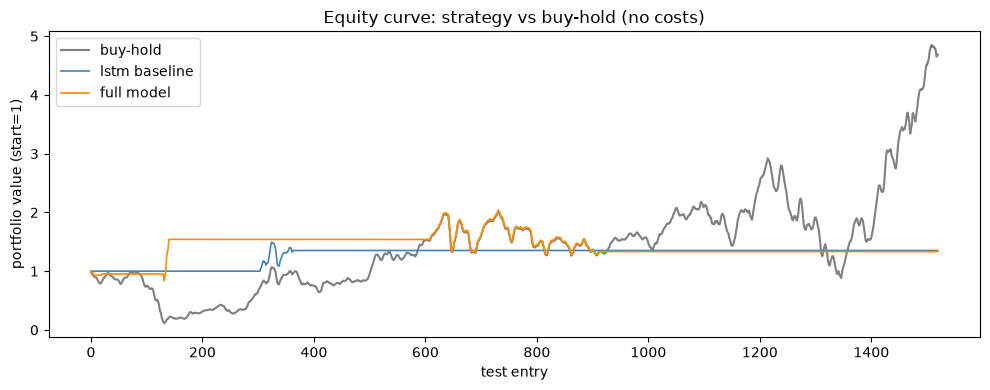

In [16]:
# Trading equity curve (full vs buy-hold vs lstm baseline) + per-class precision.
# Equity needs the stored series (re-run after the trading_stats change); precision works on any run.
if wf_metrics and "preds" in wf_metrics:
    from sklearn.metrics import precision_score
    _p = (np.array(wf_metrics["preds"]) > 0.5).astype(int); _t = np.array(wf_metrics["truths"]).astype(int)
    _pr = precision_score(_t, _p, average=None, labels=[0, 1], zero_division=0)
    print(f"precision DOWN={_pr[0]:.4f} UP={_pr[1]:.4f} (pooled, thr 0.5)")
    _ab = wf_metrics.get("ablation", {})
    _eq = {v: _ab[v]["trading"] for v in ("full", "lstm") if v in _ab and "equity" in _ab[v].get("trading", {}).get("strategy", {})}
    if _eq:
        _n = min(len(_eq[v]["strategy"]["equity"]) for v in _eq)
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(_eq["full"]["buyhold"]["equity"][:_n], label="buy-hold", color="gray", linewidth=1.5)
        ax.plot(_eq["lstm"]["strategy"]["equity"][:_n], label="lstm baseline", color="steelblue", linewidth=1.2)
        ax.plot(_eq["full"]["strategy"]["equity"][:_n], label="full model", color="darkorange", linewidth=1.2)
        ax.set_xlabel("test entry"); ax.set_ylabel("portfolio value (start=1)"); ax.legend()
        ax.set_title("Equity curve: strategy vs buy-hold (no costs)")
        plt.tight_layout(); plt.show()
    else:
        print("(equity skipped — re-run the pipeline cell to store the series)")
else:
    print("(equity/precision skipped — no walk-forward results)")


## Checks

Shapes, finiteness, binary labels, and proof the scalers saw the train prefix only.

**What to look at:** two OK lines = architecture matches Table 5 AND scalers saw the 70% train prefix only. If either fails, nothing downstream is trustworthy.


In [17]:
assert X_tech.shape[1:] == (lb, len(CFG.tech_cols))
assert len(y) == n_win
assert np.isfinite(X_tech).all() and np.isfinite(X_macro).all()
assert set(np.unique(y)) <= {0.0, 1.0}
raw_tech = df[list(CFG.tech_cols)].values.astype(np.float32)
assert np.allclose(feat_scaler.data_min_, raw_tech[:train_end_df].min(axis=0))

model = StockModel(CFG)  # structural guard: arch asserts must actually run (run cell leaves model=None)
if model is not None:
    assert all(hasattr(model, a) for a in ("lstm", "mlp", "news_proj", "gate"))
    assert model.lstm.hidden_size == CFG.lstm_dim
    assert model.mlp[-2].out_features == 16
    assert model.news_proj.out_features == CFG.lstm_dim
    assert model.gate.out_features == CFG.fusion_output_dim
    assert (CFG.lstm_dim + 16 + CFG.lstm_dim) == CFG.lstm_dim + 16 + CFG.lstm_dim
    if metrics and "prob" in metrics:
        assert "prob" in metrics
        assert "auc" in wf_metrics and "acc" in wf_metrics and "f1" in wf_metrics
    short_history = evaluate_model(model, df.iloc[:1], CFG)
    assert short_history["prob"] == 0.5
    assert all(
        math.isnan(value) for key, value in short_history.items() if key != "prob"
    )
    print("OK: thesis model architecture verified")

print("OK: leak-free single-notebook run passed")

OK: thesis model architecture verified
OK: leak-free single-notebook run passed


d:\projects\msdl-jci\.venv\Lib\site-packages\torch\nn\modules\rnn.py:1011: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


## Summary Report

Thesis defense results summary: model architecture, walk-forward metrics, gating weights, and key findings.

**What to look at:** Key Findings lines 1–4 are the thesis-ready sentences (dominant modality, pooled AUC, training regime, live news counts). UP/DOWN recall explains the Youden-J choice.


MSDL-JCI: Multi-Source Deep Learning for JCI Direction Prediction
Thesis Defense Summary Report
Technical: LSTM(hidden=64, lookback=28, dropout=0.2)
Macro:     MLP(3→32→16, ReLU)
News:      Frozen IndoBERT(768→64)
Fusion:    SoftGate(64+16+64→3)
Head:      Linear(64→1, BCE)
Rows=1852  Samples=1825  Range=2018-05-31→2025-12-19  UP=55.2%/DOWN=44.8%

--- Walk-Forward Results (5 splits, expanding window) ---
Fold |    AUC |    Acc |     F1 |    N
----------------------------------------
   0 | 0.5007 | 0.4803 | 0.1222 |  304
   1 | 0.5178 | 0.4408 | 0.0000 |  304
   2 | 0.4271 | 0.4737 | 0.6117 |  304
   3 | 0.5828 | 0.4211 | 0.1200 |  304
   4 | 0.6018 | 0.5033 | 0.2705 |  304
----------------------------------------
Mean | 0.5260 | 0.4638 | 0.2249 |

--- Gate Weights (α, β, γ) Summary ---
Technical (α): mean=0.3524, std=0.2869
Macro (β):     mean=0.6131, std=0.2994
News (γ):      mean=0.0345, std=0.0547


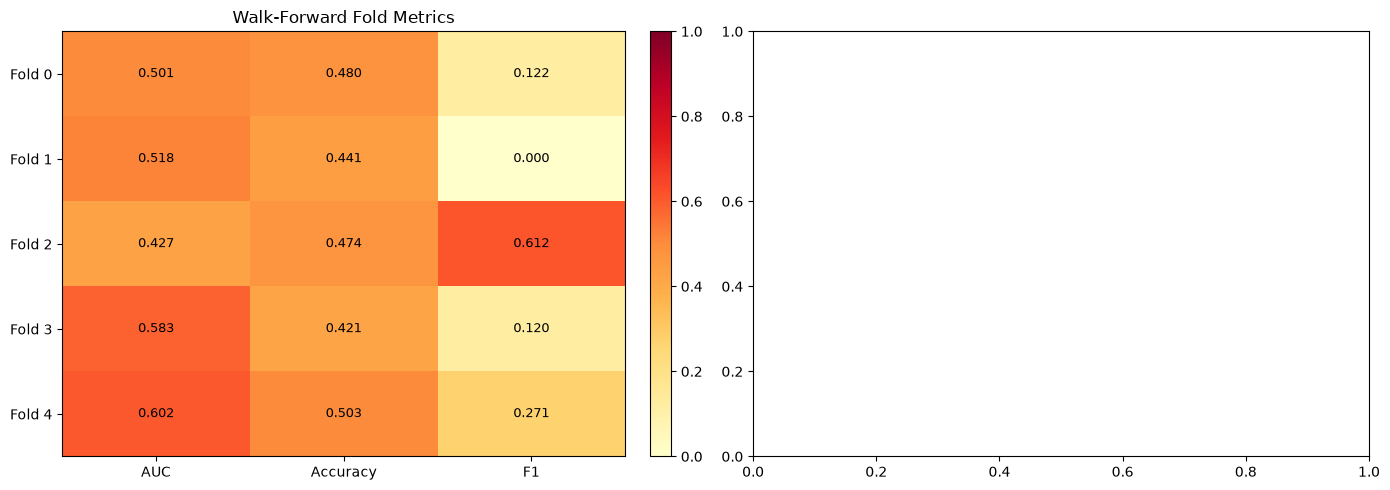

1. Dominant modality: Macro (β) (α=0.352, β=0.613, γ=0.035)
2. Walk-forward AUC=0.4988, Acc=0.4599, F1=0.2867
3. Trained per fold (Adam, weighted BCE, early stopping max100/patience8, TSS n=5)
4. News: frozen indobert-base-p1 CLS, 20784 articles {'kontan': np.int64(10275), 'cnbc': np.int64(5556), 'detik': np.int64(4953)}, 20773 on/before JCI end past-only
UP recall=0.1981, DOWN recall=0.7773


In [18]:
"""Thesis Defense Summary Report"""
print("=" * 70)
print("MSDL-JCI: Multi-Source Deep Learning for JCI Direction Prediction")
print("Thesis Defense Summary Report")
print("=" * 70)

# Model Architecture Summary (thesis Table 5)
# live news counts (corpus changes across scrapes — never hardcode)
try:
    _jmax = pd.to_datetime(frames[0]["Date"], format="mixed", errors="coerce").max()
    _nline = (f"4. News: frozen indobert-base-p1 CLS, {len(news)} articles "
              f"{dict(news['src'].value_counts())}, "
              f"{(news['day'] <= _jmax).sum()} on/before JCI end past-only")
except Exception:
    _nline = "4. News: frozen indobert-base-p1 CLS (re-run pipeline cell for counts)"
for line in [
    f"Technical: LSTM(hidden={CFG.lstm_dim}, lookback={CFG.look_back}, dropout=0.2)",
    f"Macro:     MLP({len(CFG.macro_cols)}→{'→'.join(map(str, CFG.hidden_layers))}, ReLU)",
    f"News:      Frozen IndoBERT(768→{CFG.projection_dim})",
    f"Fusion:    SoftGate({CFG.lstm_dim}+{CFG.hidden_layers[-1]}+{CFG.projection_dim}→{CFG.fusion_output_dim})",
    f"Head:      Linear({CFG.lstm_dim}→1, BCE)",
]:
    print(line)

# Data Summary
print(f"Rows={len(df)}  Samples={len(y)}  Range={dates[0]}→{dates[-1]}  UP={y.mean():.1%}/DOWN={1-y.mean():.1%}")

# Walk-Forward Results
if wf_metrics and "fold_metrics" in wf_metrics:
    fm = wf_metrics["fold_metrics"]
    print("\n--- Walk-Forward Results (5 splits, expanding window) ---")
    print(f"{'Fold':>4} | {'AUC':>6} | {'Acc':>6} | {'F1':>6} | {'N':>4}")
    print("-" * 40)
    for m in fm:
        print(f"{m['fold']:>4} | {m['auc']:>6.4f} | {m['acc']:>6.4f} | {m['f1']:>6.4f} | {m['n_samples']:>4}")
    mean_auc = np.mean([m['auc'] for m in fm])
    mean_acc = np.mean([m['acc'] for m in fm])
    mean_f1 = np.mean([m['f1'] for m in fm])
    print("-" * 40)
    print(f"{'Mean':>4} | {mean_auc:>6.4f} | {mean_acc:>6.4f} | {mean_f1:>6.4f} |")

    # Gating weights summary
    if "weights_list" in wf_metrics:
        weights = np.array(wf_metrics["weights_list"])
        print("\n--- Gate Weights (α, β, γ) Summary ---")
        print(f"Technical (α): mean={weights[:,0].mean():.4f}, std={weights[:,0].std():.4f}")
        print(f"Macro (β):     mean={weights[:,1].mean():.4f}, std={weights[:,1].std():.4f}")
        print(f"News (γ):      mean={weights[:,2].mean():.4f}, std={weights[:,2].std():.4f}")

    # Visualization: summary heatmap
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Left: fold metrics heatmap
    fold_data = np.array([[m["auc"], m["acc"], m["f1"]] for m in fm])
    im1 = ax1.imshow(fold_data, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
    ax1.set_xticks([0, 1, 2])
    ax1.set_xticklabels(["AUC", "Accuracy", "F1"])
    ax1.set_yticks(range(len(fm)))
    ax1.set_yticklabels([f"Fold {m['fold']}" for m in fm])
    ax1.set_title("Walk-Forward Fold Metrics")
    for i in range(len(fm)):
        for j in range(3):
            ax1.text(j, i, f"{fold_data[i,j]:.3f}", ha="center", va="center", fontsize=9)
    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()
else:
    print("No walk-forward results available.")

# Key Findings (guarded: summary must never crash if pipeline cell was skipped)
if not (wf_metrics and "weights_list" in wf_metrics and "preds" in wf_metrics):
    print("\n--- Key Findings ---")
    print("(skipped — run the pipeline cell first)")
else:
    w = np.array(wf_metrics["weights_list"]).mean(axis=0)
    dom = ["Technical (α)", "Macro (β)", "News (γ)"][int(np.argmax(w))]
    for line in [
        f"1. Dominant modality: {dom} (α={w[0]:.3f}, β={w[1]:.3f}, γ={w[2]:.3f})",
        f"2. Walk-forward AUC={wf_metrics['auc']:.4f}, Acc={wf_metrics['acc']:.4f}, F1={wf_metrics['f1']:.4f}",
        "3. Trained per fold (Adam, weighted BCE, early stopping max100/patience8, TSS n=5)",
        _nline,
    ]:
        print(line)
    preds = np.array(wf_metrics["preds"]) > 0.5
    truths = np.array(wf_metrics["truths"]) == 1
    print(f"UP recall={preds[truths].mean():.4f}, DOWN recall={(~preds[~truths]).mean():.4f}")
print("=" * 70)
